Projet : Anticipez les besoins en consommation de bâtiments

Notebook : Modélisation des émissions

Created by: Thomas Durand-Texte, Feb. 2023

**Table of contents**<a id='toc0_'></a>    
- 1. [Import des packages et données](#toc1_)    
  - 1.1. [import des packages](#toc1_1_)    
  - 1.2. [Paramètres graphiques et fonctions utiles](#toc1_2_)    
  - 1.3. [Chargement des données](#toc1_3_)    
  - 1.4. [Transformer](#toc1_4_)    
- 2. [Definitions](#toc2_)    
- 3. [Modélisations](#toc3_)    
  - 3.1. [Chargement des modèles entrainés dans le notebook sur la modélisation de la consommation](#toc3_1_)    
  - 3.2. [Récupération du meilleur résultat pour chaque modèle](#toc3_2_)    
  - 3.3. [Calcul de des emissons à partir de l'estimation de consommation et des proportions d'utilisation d'énergie](#toc3_3_)    

<!-- vscode-jupyter-toc-config
	numbering=true
	anchor=true
	flat=false
	minLevel=1
	maxLevel=6
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

# 1. <a id='toc1_'></a>[Import des packages et données](#toc0_)
## 1.1. <a id='toc1_1_'></a>[import des packages](#toc0_)

In [31]:
import os

import pickle
import time

import pandas as pd
pd.set_option("display.max_columns", 200)
import numpy as np
import datetime as dt
import scipy.stats as st

from sklearn import model_selection, metrics, preprocessing, linear_model, dummy

from sklearn.svm import LinearSVR, SVR
from sklearn import kernel_ridge
from sklearn.ensemble import RandomForestRegressor


from lightgbm import LGBMRegressor


import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

cm = 1./2.54

import shap
shap.initjs()

## 1.2. <a id='toc1_2_'></a>[Paramètres graphiques et fonctions utiles](#toc0_)

In [32]:
import subprocess

white_font = True
def set_theme( white_font=True ):
    """ set_theme( white_font=True ) """
    if white_font: wht, grey, blck = '0.84' , '0.5', 'k'
    else: wht, grey, blck = 'k', '0.5', '0.84'
    rc = { 'figure.facecolor':(0.118,)*3,
            'axes.labelcolor':wht,
            'axes.edgecolor':wht,
            'axes.facecolor':(0,0,0,0),
            'text.color':'white',
            'text.usetex':False,
            'text.latex.preamble':r'\usepackage[cm]{sfmath} \usepackage{amsmath}' ,
            'font.family': 'sans-serif' ,
            'font.sans-serif': 'DejaVu Sans' ,
            'xtick.color':wht,
            'ytick.color':wht,
            "axes.grid" : True,
            "grid.color": (0.7,)*3,
            "grid.linewidth": 0.4,
            "grid.linestyle": (10,5),
            'legend.edgecolor':'0.2',
            'legend.facecolor':(0.2,0.2,0.2,0.6),
            # 'legend.framealpha':'0.6',
            'pdf.fonttype':42,
            'savefig.format':'pdf',
            'savefig.transparent':True,
            'figure.dpi':150, # for better agreemet figsize vs real size
        }

    sns.set_theme( 'notebook' , rc=rc )
    return


def make_folder( path_folder ):
    path_folder = path_folder.__str__()
    try:
        if os.path.isdir( path_folder ) : return
        os.makedirs(path_folder)
    except OSError:
        pass
    return

def concat_folders(*args, **kwargs):
    """ concat_folders(*args, **kwargs)
        concatenate folders in args (strings) """
    sPath = ''
    for arg in args:
        if arg == '..': sPath = sPath[:sPath[:-1].rfind(os.sep)+1]
        else: sPath += arg
        if sPath[-1] != os.sep: sPath += os.sep
    return sPath

class Path(object):
    """ Path( s_in='', s_lim=None)
        create a path to the string s_in (default is current path)
        and stops after s_lim """
    n_Path = 0
    def __init__(self, s_in='', s_lim=None):
        """docstring."""
        if s_in == '': s_in = os.getcwd()
        if not s_lim is None:
            if s_lim in s_in:
                s_in = s_in[ :s_in.index( s_lim ) + len(s_lim) ]
        self.sPath = concat_folders(s_in)
        self.N = Path.n_Path
        Path.n_Path += 1

    def __add__(self, other):
        """ Path + str : return str """
        if isinstance(other, str): return self.sPath + other

    def __truediv__(self, other):
        """ Path / str : return path concatenated"""
        if isinstance(other, str): return Path(concat_folders(self.sPath, other))

    def __invert__(self):
        """ ~Path : return str of the path """
        return self.sPath

    def __str__(self):
        """ __str__ return str of the path """
        return self.sPath
    # __str__ #

    def makedir( self ):
        return make_folder( self )


def gs_opt( filename ):
    """ otpimisation of a pdf file with gosthscript """
    filenameTmp = filename.replace('.pdf', '') + '_tmp.pdf'
    gs = ['gs',
            '-sDEVICE=pdfwrite',
            '-dEmbedAllFonts=true',
            '-dSubsetFonts=true',             # Create font subsets (default)
            '-dPDFSETTINGS=/prepress',        # Image resolution
            '-dDetectDuplicateImages=true',   # Embeds images used multiple times only once
            '-dCompressFonts=true',           # Compress fonts in the output (default)
            '-dNOPAUSE',                      # No pause after each image
            '-dQUIET',                        # Suppress output
            '-dBATCH',                        # Automatically exit
            '-sOutputFile='+filenameTmp,      # Save to temporary output
            filename]                         # Input file

    subprocess.run(gs)                                      # Create temporary file
    subprocess.run( 'rm -f ' + filename, shell=True)            # Delete input file
    subprocess.run( 'mv -f ' + filenameTmp + " " + filename, shell=True) # Rename temporary to input file

def savefig( fig, savename, **kwargs ):
    """ savefig( fig, savename, **kwargs )
        Saves a figure with kwargs (fig.savefig( savename, **kwargs) ).
        A check is done first to determine if a folder has to be created according to savename.
        Finally, if the file is saved as .pdf, gosthscript optimisation is performed. """
    if os.sep in savename: make_folder( savename[:savename.rindex(os.sep)] )
    fig.savefig( savename, **kwargs )
    savename += '.pdf'
    if os.path.isfile( savename ): gs_opt( savename )


def image_size_from_width_and_shape( width: float, shape: tuple, ymargin=0. ):
    """ return tuple (width, height) corresponding to image shape """
    return width, width*shape[0]/shape[1]+ymargin

def image_size_from_height_and_shape( height: float, shape: tuple, xmargin=0. ):
    """ return tuple (width, height) corresponding to image shape """
    return height*shape[1]/shape[0]+xmargin, height


set_theme()
del set_theme

## 1.3. <a id='toc1_3_'></a>[Chargement des données](#toc0_)

Affichage de l'arborescence

In [33]:
def print_listdir( path=None, level=0, exclude=[] ) :
    suffix = ''
    if level > 0:
        suffix = ' |-'* level
    vals = os.listdir( path )
    vals.sort()
    if path is None:
        path = ''
    for val in vals:
        if val in exclude: continue
        print( suffix, val)
        if os.path.isdir( path + val):
            print_listdir( path + val + '/', level+1, exclude )

print_listdir( exclude=['.venv', 'ressources', 'models', 'devel'] )

 Exploration_v0.ipynb
 Figures
 |- PCA_eboulis.pdf
 |- PCA_heatmap.pdf
 |- SHAP_outlier.html
 |- SHAP_outlier.pdf
 |- SHAP_outlier.png
 |- categories.pdf
 |- correl_engineered.pdf
 |- correl_init.pdf
 |- feature_importance.pdf
 |- feature_importance_without_outliers.pdf
 |- histo_Nrg_GFA_Buildings_log.pdf
 |- histo_SiteEnergyUseWN(kBtu)_log.pdf
 |- histo_TotalGHGEmissions_log.pdf
 |- mathafix-bourse.pdf
 |- mathafix-bourse.svg
 |- outliers_compliant.pdf
 |- prop_energies.pdf
 |- results
 |- |- dummy_median.pdf
 |- |- elastic_net.pdf
 |- |- kernel_SVR_rbf.pdf
 |- |- kernel_ridge_polynomial.pdf
 |- |- kernel_ridge_rbf.pdf
 |- |- light_GBM.pdf
 |- |- linear_SVR.pdf
 |- |- random_forest.pdf
 |- results_conso
 |- |- dummy_median.pdf
 |- |- elastic_net.pdf
 |- |- kernel_SVR_rbf.pdf
 |- |- kernel_ridge_polynomial.pdf
 |- |- kernel_ridge_rbf.pdf
 |- |- light_GBM.pdf
 |- |- linear_SVR.pdf
 |- |- random_forest.pdf
 |- results_conso.pdf
 |- results_conso_without_outliers.pdf
 |- results_emissions

Chargement des données

In [34]:
path = 'data/cleaned/'
filename = '2016_Building_Energy_Benchmarking'
compression = 'gzip'

df = pd.read_pickle( r'{:}{:}.pkl'.format(path, filename), compression=compression )

df = pd.read_pickle( r'{:}{:}.pkl'.format(path, filename), compression=compression)
df_hotencoding_usetype = pd.read_pickle( r'{:}{:}_usetype.pkl'.format(path, filename), compression=compression)
df_hotencoding_location = pd.read_pickle( r'{:}{:}_location.pkl'.format(path, filename), compression=compression)
df_annexe = pd.read_pickle( r'{:}{:}_annexe.pkl'.format(path, filename), compression=compression)

with open( path + filename + 'features_log', 'rb') as file:
    features_log = pickle.load( file )

print('features_log:', features_log)
print('df:', df.shape)
print('df_hotencoding_usetype:', df_hotencoding_usetype.shape)
print('df_hotencoding_location:', df_hotencoding_location.shape)
print('df_annexe:', df_annexe.shape)
print('df columns:', df.columns.tolist())

features_log: ['NumberofBuildings', 'NumberofFloors', 'GFA_per_floor', 'sqrt_GFA_per_floor']
df: (1551, 13)
df_hotencoding_usetype: (1551, 18)
df_hotencoding_location: (1551, 13)
df_annexe: (1551, 12)
df columns: ['AgeOfBuilding(s)', 'CouncilDistrictCode', 'Latitude', 'Longitude', 'NumberofBuildings', 'NumberofFloors', 'prop_SteamUse', 'prop_Electricity', 'prop_NaturalGas', 'GFA_per_floor', 'sqrt_GFA_per_floor', 'SiteEnergyUseWN(kBtu)', 'TotalGHGEmissionsWN']


In [35]:
n_scale_X = 3
features_ordered = ['AgeOfBuilding(s)',
'Latitude', 'Longitude',
'NumberofBuildings', 'NumberofFloors',
'GFA_per_floor', 'sqrt_GFA_per_floor',
'prop_SteamUse', 'prop_Electricity', 'prop_NaturalGas',
'SiteEnergyUseWN(kBtu)', 'TotalGHGEmissionsWN']

df = df[features_ordered]
to_drop = [ 'TotalGHGEmissionsWN' ]

y_emissions = df['TotalGHGEmissionsWN'].values.copy()

df.drop( columns=to_drop, inplace=True )



n_continuous = df.shape[1] -1

# df = pd.concat( (df, df_hotencoding_location, df_hotencoding_usetype), axis=1 )
df = pd.concat( (df, df_hotencoding_usetype), axis=1 )
print('df shape:', df.shape)

sr_loc = df.isna().sum(1) == 0

df = df.loc[ sr_loc, :]

target = 'SiteEnergyUseWN(kBtu)'
y = df[target]
df = df.drop( columns=target ).copy()

print('df shape:', df.shape)
print('y shape:', y.shape)


df.head()

df shape: (1551, 29)
df shape: (1551, 28)
y shape: (1551,)


,AgeOfBuilding(s),Latitude,Longitude,NumberofBuildings,NumberofFloors,GFA_per_floor,sqrt_GFA_per_floor,prop_SteamUse,prop_Electricity,prop_NaturalGas,ohe0 data center,ohe0 education,ohe0 entertainment - public assembly,ohe0 industrial,ohe0 lifestyle center,ohe0 medical,ohe0 medical office,ohe0 office,ohe0 other,ohe0 other - entertainment/public assembly,ohe0 residential - hotel,ohe0 restaurant,ohe0 science,ohe0 self-storage facility,ohe0 services,ohe0 store,ohe0 utility,ohe0 worship facility
0,89,47.61220,-122.33799,1,12,7369.500000,85.845792,0.277302,0.546060,0.176638,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
1,20,47.61317,-122.33393,1,11,8045.636364,89.697471,0.000000,0.386609,0.613391,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.947775,0.052225,0.0,0.0,0.0,0.0,0.0,0.0
2,47,47.61393,-122.33810,1,41,18521.756098,136.094659,0.297113,0.682307,0.020579,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.996182,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
3,90,47.61412,-122.33664,1,10,6132.000000,78.307088,0.325913,0.407519,0.266567,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
4,36,47.61375,-122.34047,1,18,6310.000000,79.435508,0.000000,0.378802,0.621198,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.086855,0.000000,0.0,0.0,0.0,0.0,0.0,0.0


## 1.4. <a id='toc1_4_'></a>[Transformer](#toc0_)

In [36]:
GFA_ref = df_annexe['PropertyGFABuilding(s)']

In [37]:
class Transformer:
    def __init__( self, type='identity', power=1, filename=None ):
        if filename is None:
            self.type = type
            self.cst = 0.
            self.y_min = 0.
        else:
            self.load( filename )
        return
    def save( self, filename ):
        with open( filename, 'wb' ) as file:
            pickle.dump( (self.type, self.cst, self.y_min), file )
    def load( self, filename ):
        with open( filename, 'rb' ) as file:
            self.type, self.cst, self.y_min = pickle.load( file )
    def get_dico_func(self):
        return {'func':self.transform, 'inverse_func':self.reverse }
    def fit( self, y ):
        if self.type == 'identity':
            return self
        if self.type == 'log':
            self.y_min = 1 - min( y.min(), 0)
            self.cst = -np.log( y + self.y_min ).mean()
            return self
        return self
    def transform( self, y ):
        if self.type == 'identity':
            return y
        if self.type == 'log':
            return np.log( y + self.y_min ) + self.cst
    def inverse_transform( self, y ):
        if self.type == 'identity':
            return y
        if self.type == 'log':
            return  np.exp( y - self.cst ) - self.y_min

class Y_Transformer_Ref:
    def __init__(self, y, ref, indices_train, indices_test):
        """class to manage y with ref

        Args:
            y (ndarray): _description_
            ref (ndarray): _description_
            indices_train (ndarray int): _description_
            indices_test (ndarray int): _description_
        """
        self.y = {'train': y[indices_train], 'test': y[indices_test]}
        self.ref = {'train': ref[indices_train], 'test': ref[indices_test]}
        return
    def get_y(self, dataset ):
        return self.y[dataset]
    def get_y_pred(self, dataset ):
        """

        Args:
            dataset (string): train | test

        Returns:
            ndarray: y/ref
        """
        return self.y[dataset] / self.ref[dataset]
    def y_predict_to_y(self, dataset, y_pred):
        """transforms y_predict back to y

        Args:
            dataset (string): train | test
            y_pred (ndarray): _description_

        Returns:
            ndarray: y_pred*ref
        """
        return y_pred * self.ref[dataset]

class Model_With_Y_Transform:
    def __init__( self, model=None, transformer=None, y_container=None, filepath=None ):
        self.y_container = y_container
        if filepath is None:
            self.model = model
            self.transformer = transformer
            self.best_params_ = {}
        else:
            self.load( filepath )
        return
    def save( self, filepath ):
        if filepath[-1] != os.sep:
            filepath += os.sep
        pickle.dump((self.model, self.best_params_), open(filepath + 'model.pkl', 'wb'))
        self.transformer.save( filepath + 'transformer.pkl' )
        return self
    def load( self, filepath ):
        self.model, self.best_params_ = pickle.load(open(filepath + 'model.pkl', 'rb'))
        self.transformer = Transformer( filename=filepath + 'transformer.pkl' )
        return self
    def fit( self, X, dataset='train' ):
        """fit model with y_to_predict from y_container

        Args:
            X (ndarray): should be the X_train
            dataset (string): Default="train" should be "train", but can work with "test" if X_test is p

        Returns:
            _type_: self
        """
        y = self.y_container.get_y_pred( dataset )
        self.transformer.fit( y )   # TODO: ajout d'une fonction fit_transform
        self.model.fit( X, self.transformer.transform(y) )
        if hasattr(self.model, 'best_params_'):
            self.best_params_ = self.model.best_params_
        return self
    def predict( self, X, dataset ):
        return self.y_container.y_predict_to_y( dataset, self.transformer.inverse_transform( self.model.predict( X ) ) )

In [38]:
df.columns

Index(['AgeOfBuilding(s)', 'Latitude', 'Longitude', 'NumberofBuildings',
       'NumberofFloors', 'GFA_per_floor', 'sqrt_GFA_per_floor',
       'prop_SteamUse', 'prop_Electricity', 'prop_NaturalGas',
       'ohe0 data center', 'ohe0 education',
       'ohe0 entertainment - public assembly', 'ohe0 industrial',
       'ohe0 lifestyle center', 'ohe0 medical', 'ohe0 medical office',
       'ohe0 office', 'ohe0 other',
       'ohe0 other - entertainment/public assembly',
       'ohe0 residential - hotel', 'ohe0 restaurant', 'ohe0 science',
       'ohe0 self-storage facility', 'ohe0 services', 'ohe0 store',
       'ohe0 utility', 'ohe0 worship facility'],
      dtype='object')

In [39]:
y_transfomer_ref = Y_Transformer_Ref( y.values, GFA_ref.values, np.arange(len(y)), np.arange(0) )
y2 = y_transfomer_ref.get_y_pred( 'train' )
sr_y_transformed = pd.Series( y2 )
describe_y = sr_y_transformed.describe()
display( describe_y )

IQ = describe_y['75%'] - describe_y['25%']

print('number of buildings:', len(y))

is_lower_outliers = sr_y_transformed < ( describe_y['25%'] - 1.5*IQ )
print('Lower outliers:', is_lower_outliers.sum())
print( sr_y_transformed[ is_lower_outliers ])

is_higher_outliers = sr_y_transformed > ( describe_y['75%'] + 1.5*IQ )
print('\nHigher outliers:', is_higher_outliers.sum() )
print( sr_y_transformed[ is_higher_outliers ])

is_ok = (sr_y_transformed > ( describe_y['25%'] - 1.5*IQ ) ) & ( sr_y_transformed < ( describe_y['75%'] + 1.5*IQ ) )
print('number ok ok:', is_ok.sum())

count    1551.000000
mean       82.155833
std       120.377646
min        -1.183965
25%        36.700921
50%        55.396589
75%        89.131084
max      3434.854960
dtype: float64

number of buildings: 1551
Lower outliers: 0
Series([], dtype: float64)

Higher outliers: 151
5       206.782802
30      927.417754
41      293.703867
53      201.506853
54      180.330959
           ...    
1510    194.332551
1533    183.292926
1543    414.552960
1544    263.272926
1548    452.775783
Length: 151, dtype: float64
number ok ok: 1400


In [40]:
class X_Scaler:
    def __init__(self, n_continuous):
        self.n_continuous = n_continuous
        return
    def fit(self, X ):
        self.scaler = preprocessing.RobustScaler().fit( X[:,:self.n_continuous] )
        return self
    def transform(self, X):
        return np.hstack( ( self.scaler.transform(X[:,:self.n_continuous]), X[:,self.n_continuous:]) )
    def scale_train_and_test(self, X_train, X_test):
        return {'train':self.transform(X_train), 'test':self.transform(X_test)}

X = df.values
features_X = df.columns.tolist()

for feature in features_log:
    i = df.columns.get_loc( feature )
    X[:,i] = np.log( X[:,i] + (1 - min(0,X[:,i].min())) )

y_emissions2 = y_emissions[is_ok.values]
X2 = X[is_ok.values, :]
y2 = y[is_ok.values]
GFA_ref2 = GFA_ref[is_ok.values]

indices = np.arange( is_ok.sum() )

y_transfomer_ref = Y_Transformer_Ref( y2.values, GFA_ref2.values, np.arange(len(y2)), np.arange(0) )

ytmp = y_transfomer_ref.get_y_pred( 'train' )
transformers = {'y': Transformer( 'log' ).fit( ytmp ) }
y_transformed = transformers['y'].transform(ytmp)

X_train, X_test, indices_train, indices_test = model_selection.train_test_split( X2, indices, random_state=0,
        stratify=preprocessing.KBinsDiscretizer( n_bins=12, encode='ordinal').fit_transform( y_transformed.reshape(-1,1) ).ravel() )

y_transfomer_ref = Y_Transformer_Ref( y2.values, GFA_ref2.values, indices_train, indices_test )


print('X', X.shape)
print('X2', X2.shape)
print( 'X_train:', X_train.shape )
print( 'X_test:', X_test.shape )

X (1551, 28)
X2 (1400, 28)
X_train: (1050, 28)
X_test: (350, 28)


***
# 2. <a id='toc2_'></a>[Definitions](#toc0_)

Définition des modèles

Fonctions

In [41]:
def plot_results0( label, dico_results ):

    n0, ncb, nhist = 4, 0,2
    width = 20*cm
    fig = plt.figure( figsize=(width,width*(n0+nhist)/(2*n0+ncb)) )
    gs = fig.add_gridspec( n0+nhist, 2*n0+ncb, hspace=2 )

    fig.suptitle( label )

    for i, dataset in enumerate( ['train', 'test'] ):
        y_pred = dico_results[label][ f'y_pred {dataset}' ]
        y = y_transfomer_ref.get_y(dataset)
        i0,i1 = i*(n0+ncb),i*(n0+ncb)+n0
        ax = fig.add_subplot(gs[:n0, i0:i1])

        ax.set_title( f'{dataset} set')
        ax.set_ylabel( 'prediction ' )
        ax.set_xlabel( 'target' )
        ax.set_yscale('log')
        ax.set_xscale('log')
        scttr = ax.scatter( y, y_pred, s=2, c= y_transfomer_ref.get_y_pred(dataset), vmin=y_pred_min, vmax=y_pred_max )
        if dataset == 'train':
            i0,i1 = n0,n0+ncb
            cax = fig.add_axes([0.25, 0.48, 0.22, 0.015])
            cb = fig.colorbar( scttr, ax=ax, cax=cax, orientation='horizontal', label='Energy per GFA (kbtu/sf)', alpha=0.7 )
            cb.ax.tick_params(labelsize=7)
            cb.set_label( 'Energy per GFA (kbtu/sf)', size=7)
        xy_optim = [y.min(), y.max()]
        ax.loglog( xy_optim, xy_optim, 'r', label='optimal fit' )
        ax = fig.add_subplot(gs[n0:, i*(n0+ncb):i*(n0+ncb)+n0])

        ax.hist( 100*(y_pred-y)/np.abs(y), bins=60 )
        ax.set_xlabel('Residual (%)')
    gs.tight_layout(fig)
    return


def results_to_df( dico_results ):
    scores = {
        'RMSE': lambda y_true,y_pred: np.sqrt(metrics.mean_squared_error(y_true,y_pred)),
        'R2 score': metrics.r2_score,
        'MAPE': metrics.mean_absolute_percentage_error,
        }
    
    index = pd.MultiIndex.from_tuples( [('', 'training time (sec.)')]
                    + [(score,dataset) for score in scores for dataset in ['train', 'test'] ] )
    

    df_results = pd.DataFrame( index=index )
    for (name, results) in dico_results.items():
        df_results[name] = [results['training time']] \
            + [ score(y_transfomer_ref.get_y(dataset), dico_results[name][ f'y_pred {dataset}']) for score in scores.values() for dataset in ['train', 'test'] ]
    return df_results

def print_results( dico_results ):
    display( results_to_df( dico_results ).round(2) )
    print( f"{'modèle':30} | Meilleur(s) hyperparamètre(s) sur le jeu d'entraînement")
    for name in modeles:
        model = dico_results[name]['model']
        print('{:30} |'.format(name), ', '.join([ f'{param}: {value}' for param,value in model.best_params_.items() ]) )
    return

def plot_results( dico_results ):
    for name in modeles:
        model = dico_results[name]['model']
        plot_results0( name, dico_results )
    return

***
# 3. <a id='toc3_'></a>[Modélisations](#toc0_)

## 3.1. <a id='toc3_1_'></a>[Chargement des modèles entrainés dans le notebook sur la modélisation de la consommation](#toc0_)

In [42]:
def load_models( path_save ):
    models = {}
    path_save = os.path.join(path_save, '')
    for name in os.listdir( path_save ):
        tmp = os.path.join( path_save, name, '' )
        results = pickle.load( open( tmp + 'dict.pkl', 'rb' ) )
        results['model'] = Model_With_Y_Transform( filepath=tmp )
        models[name.replace('_', ' ')] = results
    return models

In [43]:
path_save = './data/models_without_outliers/'

scaler = X_Scaler( n_scale_X ).fit( X_train )
dico_X_scaled = scaler.scale_train_and_test( X_train, X_test )
dico_X = {'train':X_train, 'test':X_test}

dico_data = {0:dico_X, 1:dico_X_scaled, 2:dico_X, 3:dico_X_scaled}

results_0 = load_models( os.path.join( path_save, 'raw', '') )
results_1 = load_models( os.path.join( path_save, 'Xscaled', '') )
results_2 = load_models( os.path.join( path_save, 'ylog', '') )
results_3 = load_models( os.path.join( path_save, 'Xscaled_ylog', '') )

## 3.2. <a id='toc3_2_'></a>[Récupération du meilleur résultat pour chaque modèle](#toc0_)

dummy median  elastic net  linear SVR  \
         training time (sec.)          1.18         0.93        0.32   
RMSE     train                   9338477.46   4214801.16  4204980.43   
         test                    5792695.44   4867280.94  4842763.99   
R2 score train                         0.86         0.97        0.97   
         test                          0.70         0.79        0.79   
MAPE     train                         0.88         0.57        0.57   
         test                          0.77         0.59        0.59   

                               kernel ridge polynomial  kernel ridge rbf  \
         training time (sec.)                    11.96              9.75   
RMSE     train                              4206663.66        3362549.37   
         test                               4830060.37        5105612.27   
R2 score train                                    0.97              0.98   
         test                                     0.79              0.77   
MAPE     train                                    0.57              0.51   
         test                                     0.59              0.54   

                               kernel SVR rbf  random forest   light GBM  
         training time (sec.)            6.34         100.32      151.45  
RMSE     train                     4108166.76     8694302.84  1380303.17  
         test                      4526660.98     5077604.82  4855899.69  
R2 score train                           0.97           0.88        1.00  
         test                            0.82           0.77        0.79  
MAPE     train                           0.55           0.27        0.24  
         test                            0.56           0.51        0.65

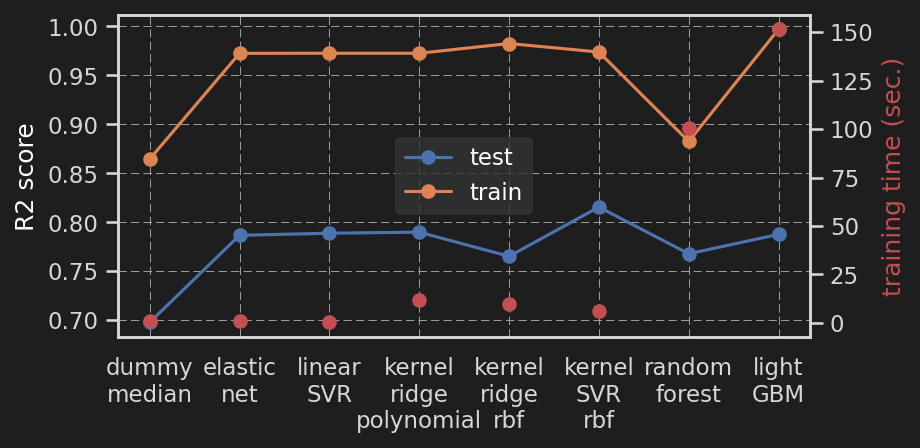

In [44]:
all_results = [results_0, results_1, results_2, results_3 ]
all_df_results = [ results_to_df( results )  for results in all_results ]
best_results = {}
best_models = pd.DataFrame( index=all_df_results[0].index )
inds_best = {}
for name in results_0:
    # recherche du meilleur résultat pour le R2 sur le test set
    i_best = np.argmax([ all_df_results[i][name][ ('R2 score', 'test') ] for i in range(4) ] )
    inds_best[name] = i_best
    best_models[name] = all_df_results[i_best][name]
    best_results[name] = all_results[i_best][name]

display( best_models.round(2) )
names = [name.replace(' ', '\n') for name in results_0]

fig, ax = plt.subplots( figsize=(16*cm, 8*cm))

ax.plot( names, best_models.loc[ ('R2 score', 'test') , : ] , 'o-', label='test')
ax.plot( names, best_models.loc[ ('R2 score', 'train') , : ] , 'o-', label='train')
ax.legend()
ax.set_ylabel( 'R2 score' )

ax = ax.twinx()
ax.plot( names, best_models.loc[ ('', 'training time (sec.)') , : ] , 'ro', label='train')
ax.set_ylabel( 'training time (sec.)', color='r' )
ax.grid( visible=False )

fig.tight_layout()

In [45]:
df.columns

Index(['AgeOfBuilding(s)', 'Latitude', 'Longitude', 'NumberofBuildings',
       'NumberofFloors', 'GFA_per_floor', 'sqrt_GFA_per_floor',
       'prop_SteamUse', 'prop_Electricity', 'prop_NaturalGas',
       'ohe0 data center', 'ohe0 education',
       'ohe0 entertainment - public assembly', 'ohe0 industrial',
       'ohe0 lifestyle center', 'ohe0 medical', 'ohe0 medical office',
       'ohe0 office', 'ohe0 other',
       'ohe0 other - entertainment/public assembly',
       'ohe0 residential - hotel', 'ohe0 restaurant', 'ohe0 science',
       'ohe0 self-storage facility', 'ohe0 services', 'ohe0 store',
       'ohe0 utility', 'ohe0 worship facility'],
      dtype='object')

## 3.3. <a id='toc3_3_'></a>[Calcul de des emissons à partir de l'estimation de consommation et des proportions d'utilisation d'énergie](#toc0_)
Les meilleurs résultats train et test cumulé sont obtenus pour le modèle "kernel SVR rbf". Le temps de calcul étant plus faible que pour le random forest, et ce dernier présentant probablement de l'over-fitting sur le jeu d'entrainement, le modèle "kernel SVR rbf" semble le mieux adapté pour la présente étude (estimation de la consommation et des émissions).

> Au final, assez peu de donnée sont disponibles, donc le calcul du R2 peut être fortement impacté par quelques éléments

R2 scores:


,dummy median,elastic net,linear SVR,kernel ridge polynomial,kernel ridge rbf,kernel SVR rbf,random forest,light GBM
train,0.85,0.95,0.95,0.95,0.97,0.96,0.89,1.00
test,0.68,0.80,0.80,0.80,0.79,0.83,0.81,0.82


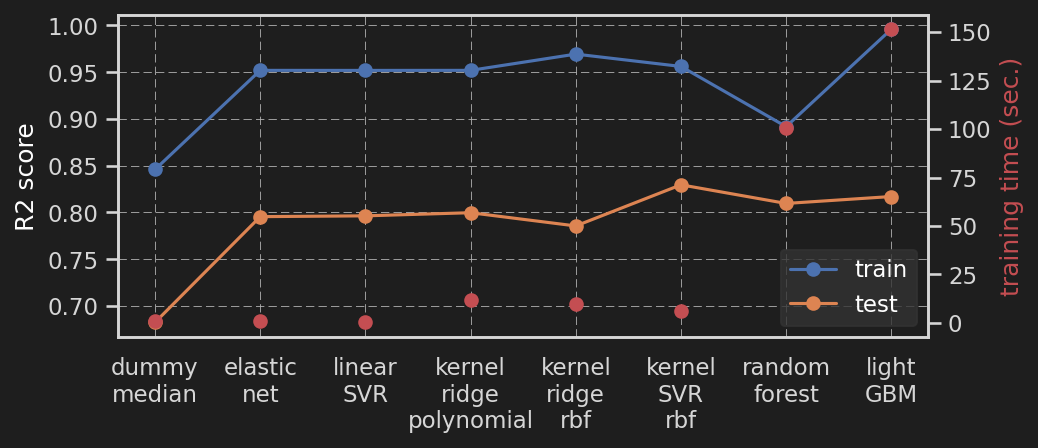

In [47]:
dico_y = { 'train':y_emissions2[indices_train], 'test':y_emissions2[indices_test] }

def energies_to_emissions( elec_kBtu, steam_kBtu, gas_kBtu):
    return 1e-3 *( # conversion kg->tons
            0.4535924*( # conversion lbs-> kg
                (52.44e-3/3.412142) * elec_kBtu # conversion kBtu->kWh->lbs
                + 170.17e-3 * steam_kBtu) # conversion kBtu->lbs
                + 53.11e-3 * gas_kBtu ) # coonversion kBtu->kg

X_prop_energy = df[ [ 'prop_Electricity', 'prop_SteamUse', 'prop_NaturalGas' ]].values[is_ok,:]
X_prop_energy = {'train': X_prop_energy[indices_train], 'test':X_prop_energy[indices_test] }

dico_y_pred = {}
results_emissions = pd.DataFrame( index=['train', 'test'])
for name in best_results:
    R2 = {}
    dico_y_pred[name] = {}
    for dataset in ['train', 'test']:
        conso = best_results[name][f'y_pred {dataset}']
        y_pred = energies_to_emissions( *(X_prop_energy[dataset].T * conso.reshape(1,-1)) )
        dico_y_pred[name][dataset] = y_pred
        R2[dataset] = metrics.r2_score( dico_y[dataset], y_pred)
    results_emissions[name] = R2


fig, ax = plt.subplots( figsize=(18*cm,8*cm))
results_emissions.T.plot( y=['train', 'test'], ax=ax, style='-o')
ax.set_xticklabels( [label.get_text().replace( ' ', '\n') for label in ax.get_xticklabels()] )
# display( results_emissions.T )
ax.set_ylabel( 'R2 score' )

ax = ax.twinx()
ax.plot( names, best_models.loc[ ('', 'training time (sec.)') , : ] , 'ro', label='train')
ax.set_ylabel( 'training time (sec.)', color='r' )
ax.grid( visible=False )

fig.tight_layout()

savefig( fig, 'Figures/results_emissions.pdf')

print('R2 scores:')
results_emissions.round(2)

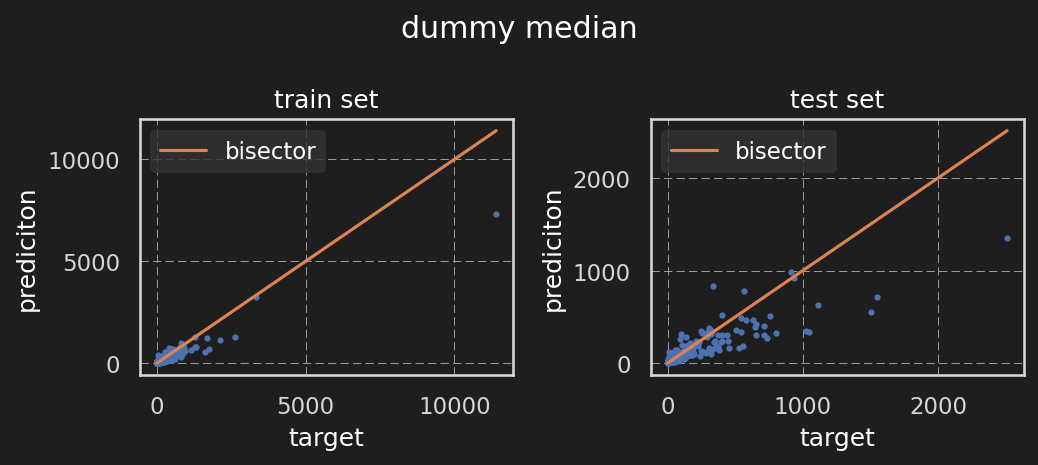

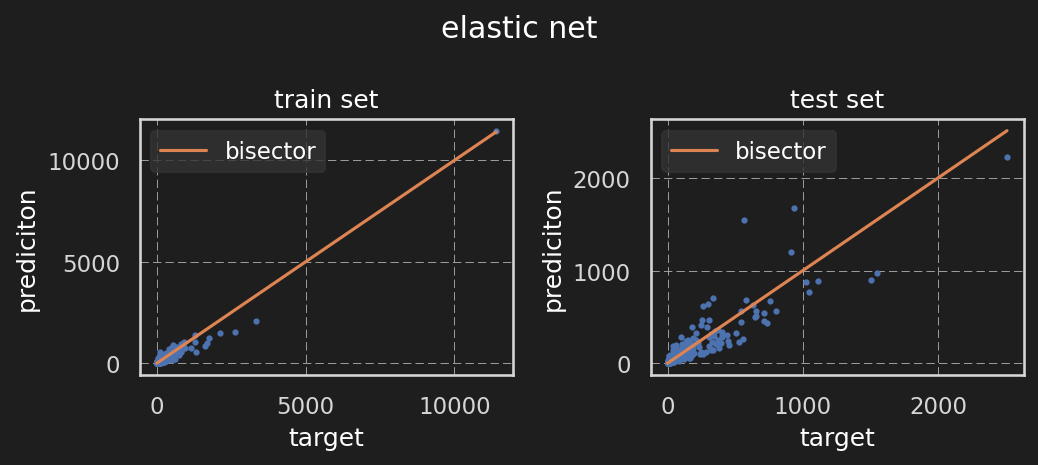

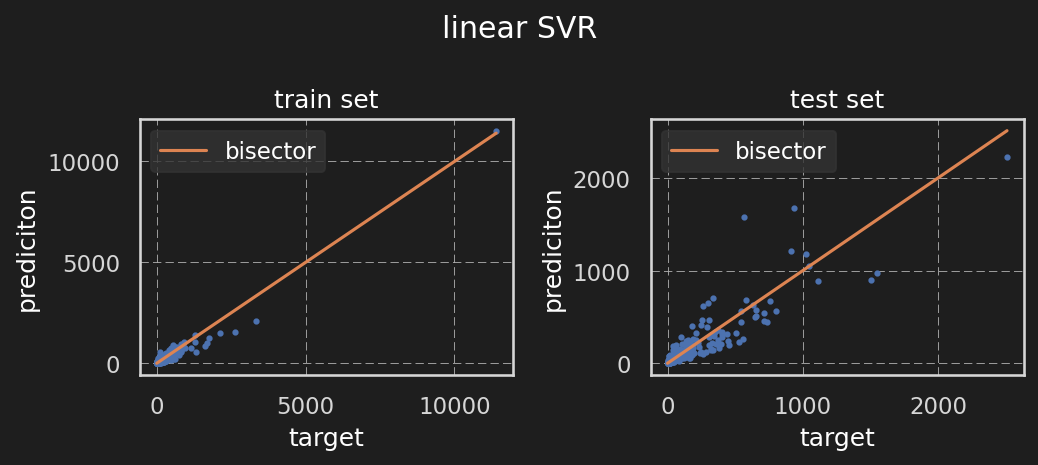

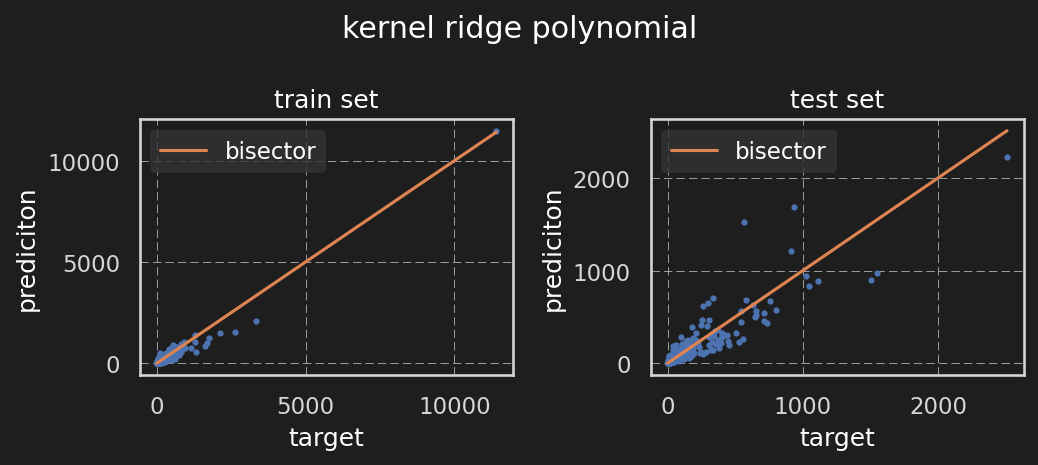

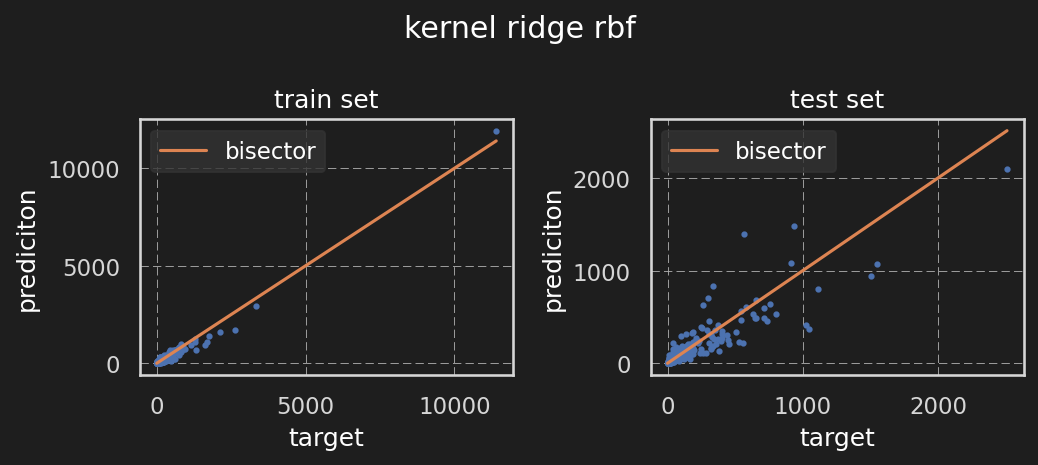

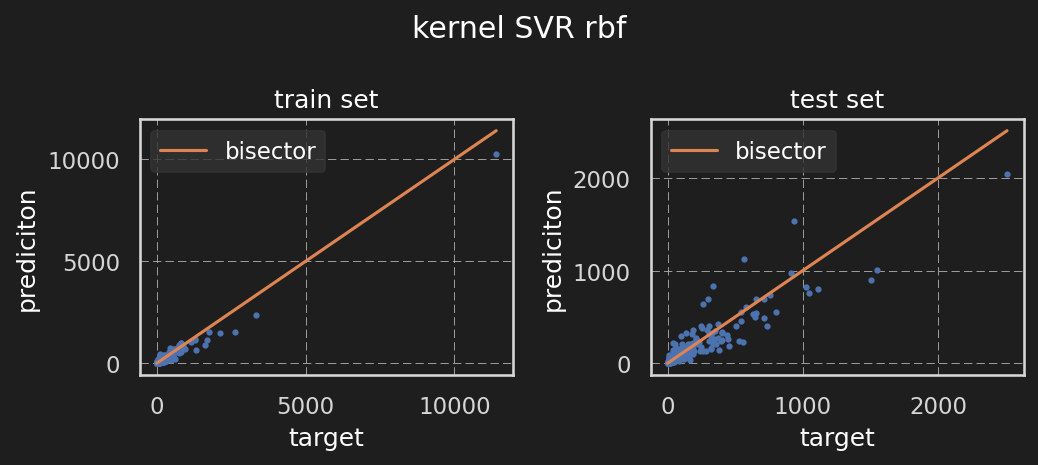

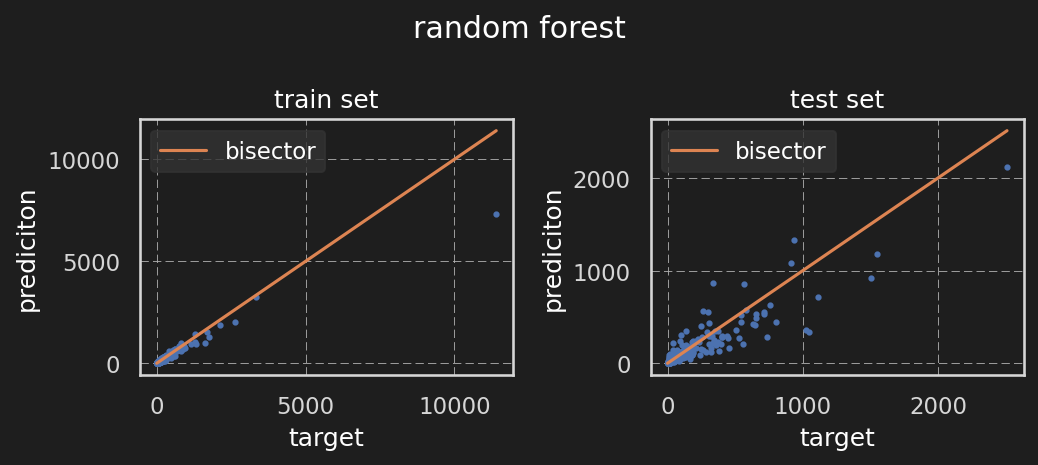

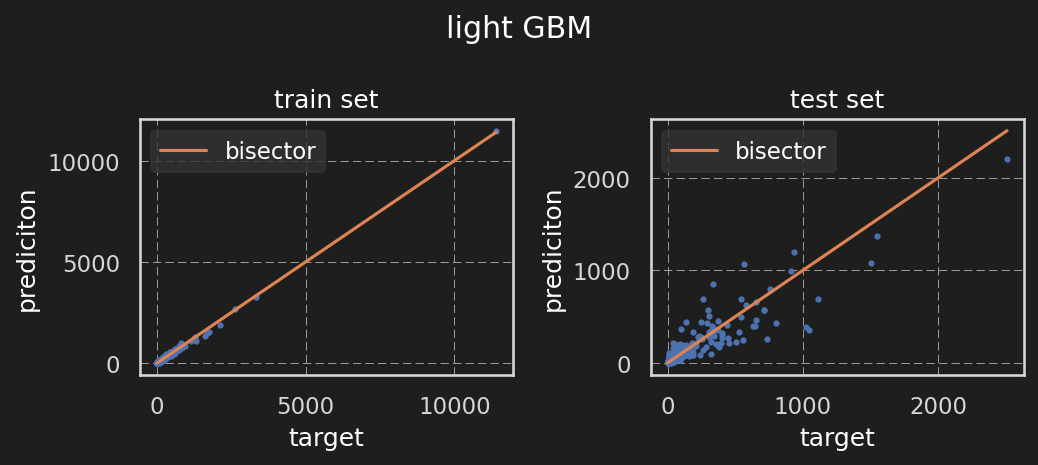

In [48]:
for name in dico_y_pred:
    fig, axs = plt.subplots( ncols=2, figsize=(18*cm,8*cm))
    for ax, dataset in zip( axs, ['train', 'test']):
        vmax = dico_y[dataset].max()
        ax.plot( dico_y[dataset], dico_y_pred[name][dataset], 'o', markersize=2 )
        ax.plot( [0,vmax], [0,vmax], label='bisector')
        ax.legend()
        ax.set_xlabel('target')
        ax.set_ylabel('prediciton')
        ax.set_title( f'{dataset} set')
        fig.suptitle(name)
    fig.tight_layout()